In [29]:
from matplotlib import font_manager

for f in font_manager.fontManager.ttflist:
    if "SimHei" in f.name or "Microsoft YaHei" in f.name or "Song" in f.name:
        print(f.name)

SimHei
STSong
Microsoft YaHei
Microsoft YaHei
FangSong
Microsoft YaHei


In [ ]:
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = [
    'STSong',   # 这个是 macOS 上的宋体
    'Microsoft YaHei',
    'SimHei',
    'FangSong'
]
plt.rcParams['axes.unicode_minus'] = False

In [41]:
import sys

!{sys.executable} bridge_shm_unsupervised_preprocess_v2.py \
  --input_csv "data/民生桥_20251201_20260318.csv" \
  --output_dir "outputs/single_民生桥" \
  --epochs 60 \
  --window_size 12 \
  --stride 1 \
  --latent_dim 32 \
  --plot_top_k 4

检测窗口按 1.0d 设置：采样间隔≈10 分钟，window_size=144

========== 桥梁异常结果摘要（民生桥） ==========
总点数：202986，异常点数：39409，异常占比：19.41%
异常类型统计（中文）：
  - 系统已知离线 (known_system_gap)：25133
  - 全桥缺测 (bridge_wide_gap)：9370
  - 设备缺测 (device_gap)：4896
  - 突刺 (spike)：4
  - 跨传感器冲突 (cross_sensor_conflict)：3
  - 漂移 (drift)：2
  - 启动跳变 (startup_jump)：1
风险最高 Top8 传感器：
  - MS-0-1L-YB-1_strain: 综合分=81.19, 主导问题=系统已知离线
  - MS-0-1L-YB-2_strain: 综合分=81.20, 主导问题=系统已知离线
  - MS-0-1L-LX-1_measureDisplacement: 综合分=83.30, 主导问题=系统已知离线
  - MS-0-1L-LX-3_measureDisplacement: 综合分=83.35, 主导问题=系统已知离线
  - MS-0-1L-LX-1_beamPierRelativeDisplacement: 综合分=89.44, 主导问题=系统已知离线
  - MS-0-1L-LX-3_beamPierRelativeDisplacement: 综合分=90.67, 主导问题=系统已知离线
  - MS-0-1D-QJ-1_temperature: 综合分=93.43, 主导问题=系统已知离线
  - MS-0-1D-QJ-1_xAxisAngle: 综合分=93.43, 主导问题=系统已知离线
事件级统计（便于报告阅读）：
  - 启动跳变点数=1，系统缺测传感器小时=4188.83，设备缺测传感器小时=816.0
  - 卡滞点数=0，漂移点数=2，阶跃点数=0，突刺/噪声点数=4

处理完成。输出文件：
 - outputs/single_民生桥\cleaned_data.csv
 - outputs/single_民生桥\score_data.csv
 - outputs/single_民生桥

d:\pycode\bridge_shm_unsupervised_preprocess\bridge_shm_unsupervised_preprocess_v2.py:1334: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  df[first_col] = pd.to_datetime(df[first_col], errors="ignore")
d:\software\miniconda\envs\automl\lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] 系统找不到指定的文件。
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "d:\software\miniconda\envs\automl\lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
  File "d:\software\miniconda\envs\automl\lib\subprocess.py", line 505, in run
    with Popen(*popenargs, **kwargs) as process:
  File "d:\soft

ValueError: x and y must have same first dimension, but have shapes (9466,) and (11277,)

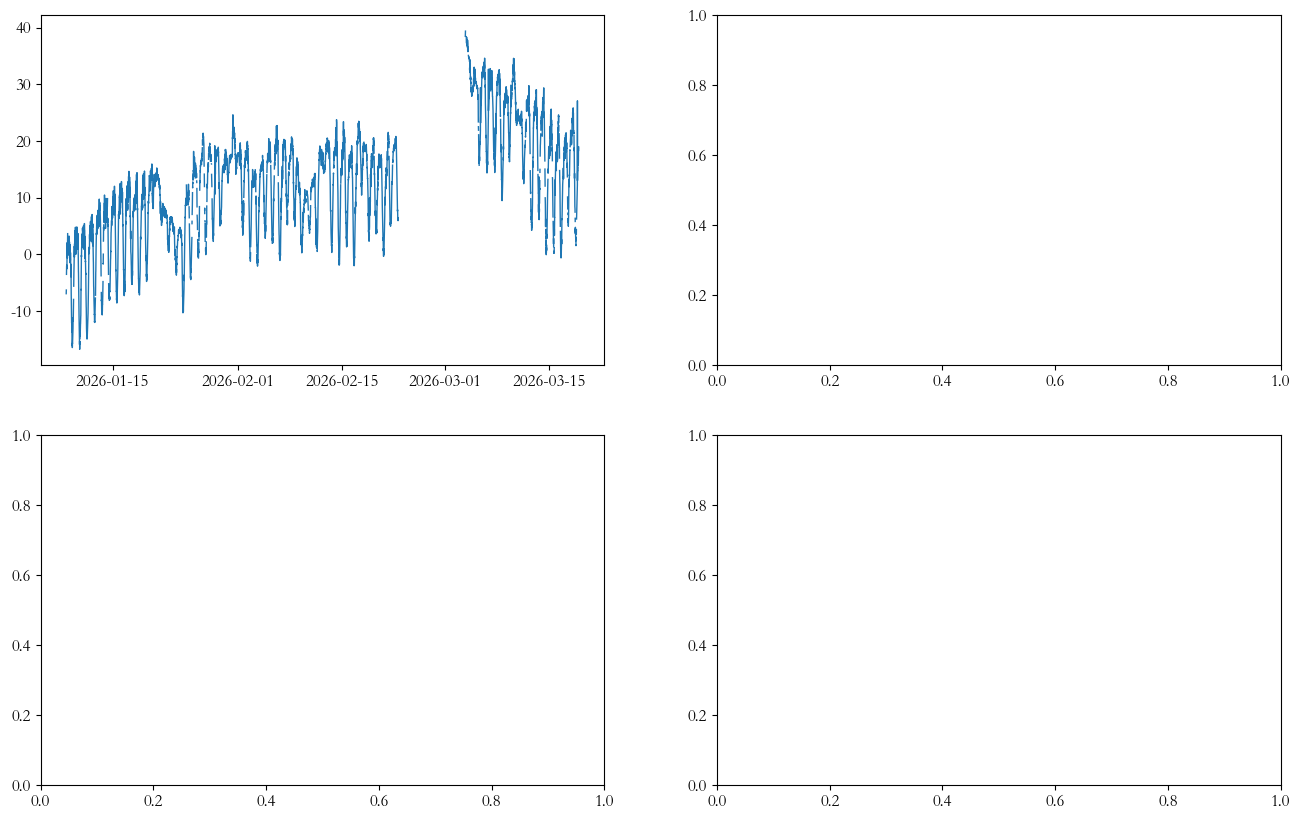

In [42]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['STSong','Microsoft YaHei', 'SimHei',  'FangSong']
plt.rcParams['axes.unicode_minus'] = False

bridge_name = "民生桥"
raw_path = f"data/{bridge_name}_20251201_20260318.csv"
out_dir = f"outputs/single_{bridge_name}"

raw = pd.read_csv(raw_path, encoding="utf-8-sig")
clean = pd.read_csv(os.path.join(out_dir, "cleaned_data.csv"), encoding="utf-8-sig")
score = pd.read_csv(os.path.join(out_dir, "score_data.csv"), encoding="utf-8-sig")
health = pd.read_csv(os.path.join(out_dir, "sensor_health_summary.csv"), encoding="utf-8-sig")
metrics = pd.read_csv(os.path.join(out_dir, "bridge_test_metrics.csv"), encoding="utf-8-sig")

# 自动找时间列
if pd.api.types.is_datetime64_any_dtype(pd.to_datetime(raw.iloc[:,0], errors='coerce')):
    t = pd.to_datetime(raw.iloc[:,0], errors='coerce')
else:
    t = np.arange(len(raw))

# 选缺失率最高的一个传感器看修复效果
sensor_cols = [c for c in raw.columns[1:] if c in clean.columns]
missing_rate = raw[sensor_cols].isna().mean().sort_values(ascending=False)
sensor = missing_rate.index[0] if len(missing_rate) else sensor_cols[0]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 图1：原始 vs 清洗
axes[0,0].plot(t, raw[sensor], label='Raw', lw=1)
axes[0,0].plot(t, clean[sensor], label='Cleaned', lw=1)
axes[0,0].set_title(f'{bridge_name} - 传感器 {sensor} 原始/清洗对比')
axes[0,0].legend()
axes[0,0].grid(alpha=0.3)

# 图2：质量分数时间序列
score_col = [c for c in score.columns if 'score' in c.lower()]
score_col = score_col[0] if score_col else score.columns[-1]
axes[0,1].plot(score[score_col], color='tab:orange', lw=1)
axes[0,1].set_title(f'{bridge_name} - 综合质量分数 ({score_col})')
axes[0,1].grid(alpha=0.3)

# 图3：传感器健康度 Top10（最差）
if 'device_health' in health.columns:
    hcol = 'device_health'
else:
    num_cols = health.select_dtypes(include=[np.number]).columns
    hcol = num_cols[0]

h = health[[health.columns[0], hcol]].copy().sort_values(hcol, ascending=True).head(10)
axes[1,0].barh(h.iloc[:,0].astype(str), h[hcol], color='tab:red', alpha=0.8)
axes[1,0].set_title(f'{bridge_name} - 健康度最低10个传感器')
axes[1,0].set_xlabel(hcol)

# 图4：桥级指标表格
axes[1,1].axis('off')
show_df = metrics.copy().T
axes[1,1].table(cellText=show_df.values,
                rowLabels=show_df.index,
                colLabels=show_df.columns,
                loc='center')
axes[1,1].set_title(f'{bridge_name} - 桥级测试指标')

plt.tight_layout()
os.makedirs("outputs/report_figs", exist_ok=True)
fig.savefig(f"outputs/report_figs/{bridge_name}_single_report.png", dpi=180)
plt.show()
print(f"Saved: outputs/report_figs/{bridge_name}_single_report.png")

In [2]:
import os
import glob
import subprocess
import sys

script = "bridge_shm_unsupervised_preprocess_v2.py"
all_csv = sorted(glob.glob("data/*.csv"))

for csv_path in all_csv:
    bridge = os.path.basename(csv_path).replace("_20251201_20260318.csv", "")
    out_dir = f"outputs/multi/{bridge}"
    os.makedirs(out_dir, exist_ok=True)

    cmd = [
        sys.executable, script,
        "--input_csv", csv_path,
        "--output_dir", out_dir,
        "--sample_days", "1",
        "--epochs", "60",
        "--window_size", "12",
        "--stride", "1",
        "--latent_dim", "32",
        "--plot_top_k", "4",
    ]

    print("Running:", " ".join(cmd))
    subprocess.run(cmd, check=True)

print("全部桥梁处理完成。")

Running: d:\software\miniconda\envs\automl\python.exe bridge_shm_unsupervised_preprocess_v2.py --input_csv data\大岗沥大桥_20251201_20260318.csv --output_dir outputs/multi/大岗沥大桥 --sample_days 1 --epochs 60 --window_size 12 --stride 1 --latent_dim 32 --plot_top_k 4
Running: d:\software\miniconda\envs\automl\python.exe bridge_shm_unsupervised_preprocess_v2.py --input_csv data\子沙大桥_20251201_20260318.csv --output_dir outputs/multi/子沙大桥 --sample_days 1 --epochs 60 --window_size 12 --stride 1 --latent_dim 32 --plot_top_k 4
Running: d:\software\miniconda\envs\automl\python.exe bridge_shm_unsupervised_preprocess_v2.py --input_csv data\新榄核大桥_20251201_20260318.csv --output_dir outputs/multi/新榄核大桥 --sample_days 1 --epochs 60 --window_size 12 --stride 1 --latent_dim 32 --plot_top_k 4
Running: d:\software\miniconda\envs\automl\python.exe bridge_shm_unsupervised_preprocess_v2.py --input_csv data\新浅海大桥_20251201_20260318.csv --output_dir outputs/multi/新浅海大桥 --sample_days 1 --epochs 60 --window_size 12 --st

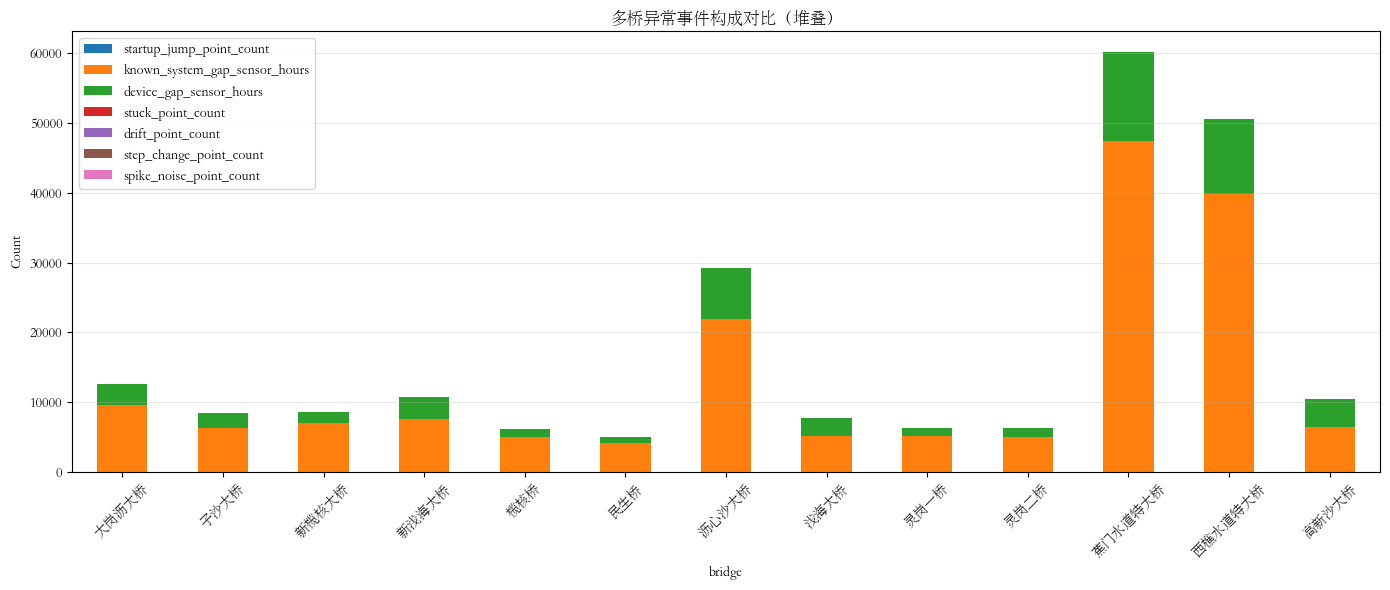

Saved: outputs/report_figs/multi_bridge_event_compare.png


In [5]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['STSong','Microsoft YaHei', 'SimHei',  'FangSong']
plt.rcParams['axes.unicode_minus'] = False

metric_files = sorted(glob.glob("outputs/multi/*/bridge_test_metrics.csv"))
event_files = sorted(glob.glob("outputs/multi/*/bridge_event_summary.csv"))

all_metrics = []
for f in metric_files:
    folder_bridge = os.path.basename(os.path.dirname(f))
    df = pd.read_csv(f, encoding="utf-8-sig")
    # 优先使用结果文件中的 bridge_name（新版 v2 已写入真实桥名），否则回退到目录名
    bridge = str(df.loc[0, "bridge_name"]) if ("bridge_name" in df.columns and len(df) > 0) else folder_bridge
    df.insert(0, "bridge", bridge)
    all_metrics.append(df)

metric_df = pd.concat(all_metrics, ignore_index=True) if all_metrics else pd.DataFrame()

all_events = []
for f in event_files:
    folder_bridge = os.path.basename(os.path.dirname(f))
    df = pd.read_csv(f, encoding="utf-8-sig")
    bridge = str(df.loc[0, "bridge_name"]) if ("bridge_name" in df.columns and len(df) > 0) else folder_bridge
    df.insert(0, "bridge", bridge)
    all_events.append(df)

event_df = pd.concat(all_events, ignore_index=True) if all_events else pd.DataFrame()

os.makedirs("outputs/report_figs", exist_ok=True)
metric_df.to_csv("outputs/report_figs/all_bridge_metrics.csv", index=False, encoding="utf-8-sig")
event_df.to_csv("outputs/report_figs/all_bridge_events.csv", index=False, encoding="utf-8-sig")

# 选常见指标列（若不存在自动跳过）
candidates = [
    "bridge_device_health",
    "bridge_availability",
    "abnormal_point_ratio",
    "mean_score",
    "p95_score",
]
use_cols = [c for c in candidates if c in metric_df.columns]

if len(metric_df) > 0 and len(use_cols) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))

    # 图A：健康度/可用率柱状图
    bar_cols = [c for c in ["bridge_device_health", "bridge_availability"] if c in metric_df.columns]
    if bar_cols:
        plot_df = metric_df[["bridge"] + bar_cols].set_index("bridge")
        plot_df.plot(kind="bar", ax=axes[0], rot=25)
        axes[0].set_title("多桥健康度与可用率对比")
        axes[0].set_ylabel("Score / %")
        axes[0].grid(axis='y', alpha=0.3)
        for container in axes[0].containers:
            axes[0].bar_label(container, fmt='%.1f', fontsize=8, padding=2)
    else:
        axes[0].text(0.5, 0.5, "无健康度/可用率字段", ha='center', va='center')
        axes[0].axis('off')

    # 图B：综合指标热力图（标准化）
    heat_df = metric_df[["bridge"] + use_cols].set_index("bridge")
    norm = (heat_df - heat_df.min()) / (heat_df.max() - heat_df.min() + 1e-9)
    im = axes[1].imshow(norm.values, aspect='auto', cmap='RdYlGn')
    axes[1].set_title("多桥综合指标热力图（归一化）")
    axes[1].set_xticks(range(len(use_cols)))
    axes[1].set_xticklabels(use_cols, rotation=25, ha='right')
    axes[1].set_yticks(range(len(norm.index)))
    axes[1].set_yticklabels(norm.index)
    # 在格子里标注原始值（可读性更好）
    raw_vals = heat_df.values
    for r in range(raw_vals.shape[0]):
        for c in range(raw_vals.shape[1]):
            axes[1].text(c, r, f"{raw_vals[r, c]:.2f}", ha='center', va='center', fontsize=7, color='black')
    fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)

    plt.tight_layout()
    fig.savefig("outputs/report_figs/multi_bridge_compare.png", dpi=180)
    plt.show()
    print("Saved: outputs/report_figs/multi_bridge_compare.png")

# 事件统计图（可选）
if len(event_df) > 0:
    num_cols = [c for c in event_df.columns if c != "bridge" and pd.api.types.is_numeric_dtype(event_df[c])]
    if num_cols:
        agg = event_df.groupby("bridge")[num_cols].sum().sort_index()
        fig = plt.figure(figsize=(14, 6))
        agg.plot(kind="bar", stacked=True, ax=plt.gca(), rot=45)
        plt.title("多桥异常事件构成对比（堆叠）")
        plt.ylabel("Count")
        plt.grid(axis='y', alpha=0.3)
        plt.tight_layout()
        plt.savefig("outputs/report_figs/multi_bridge_event_compare.png", dpi=180)
        plt.show()
        print("Saved: outputs/report_figs/multi_bridge_event_compare.png")

C:\Users\A1481\AppData\Local\Temp\ipykernel_37616\2309543574.py:190: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


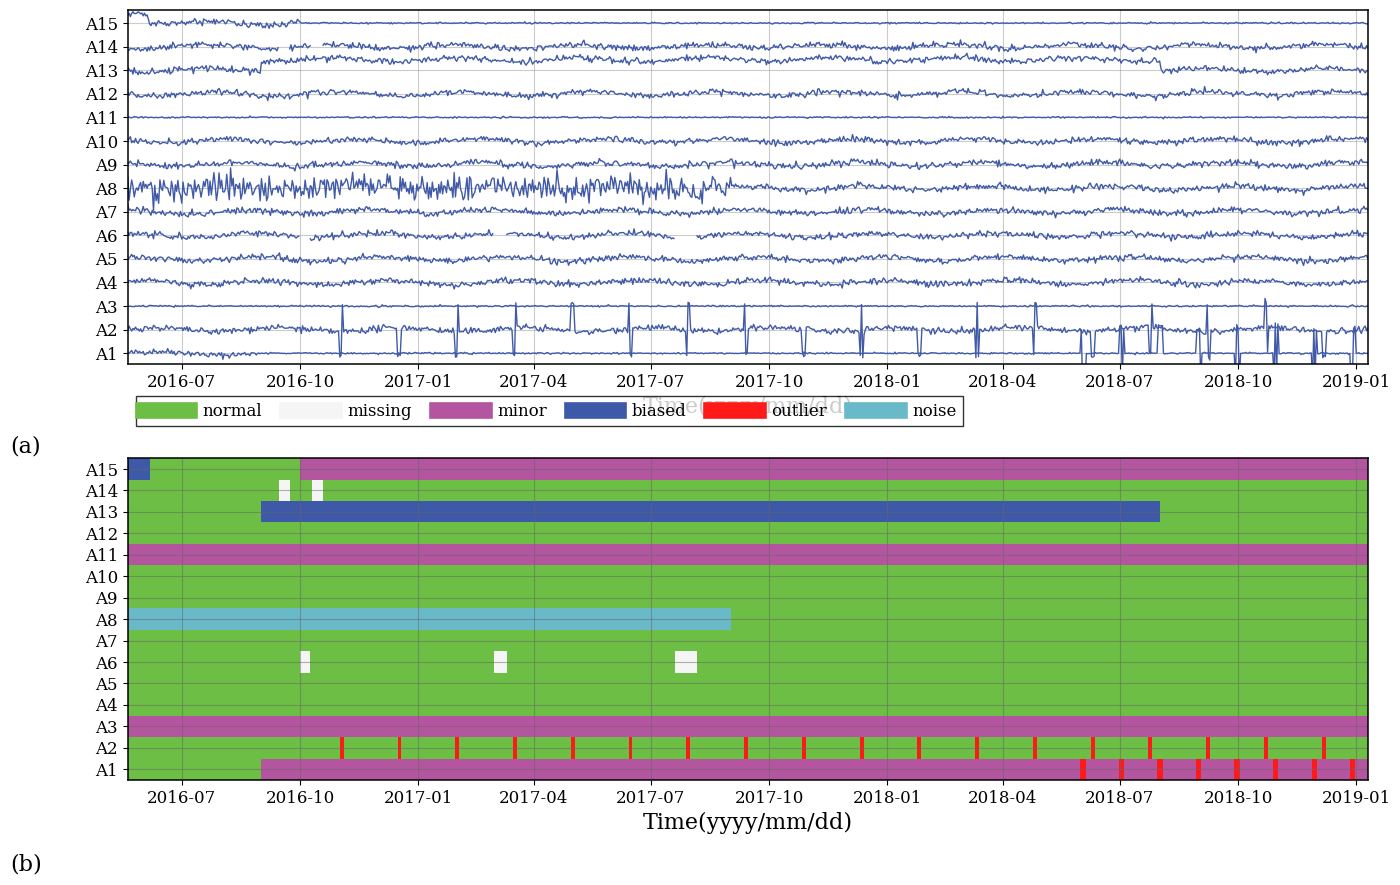

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.dates as mdates

# =========================
# 1. 造一份示例数据
# =========================
np.random.seed(42)

n_sensors = 15
sensor_names = [f"A{i}" for i in range(1, n_sensors + 1)]
time_index = pd.date_range("2016-05-20", "2019-01-10", freq="D")
n_time = len(time_index)

# 状态编码
# 0 normal, 1 missing, 2 minor, 3 biased, 4 outlier, 5 noise
status_map = {
    0: "normal",
    1: "missing",
    2: "minor",
    3: "biased",
    4: "outlier",
    5: "noise",
}

status_colors = {
    0: "#6DBE45",  # green
    1: "#F5F5F5",  # white-ish
    2: "#B455A0",  # magenta
    3: "#3E59A8",  # blue
    4: "#FF1A1A",  # red
    5: "#69B9C9",  # cyan
}

# 原始信号矩阵
X = np.zeros((n_sensors, n_time))
# 状态矩阵
S = np.zeros((n_sensors, n_time), dtype=int)

# 给每个传感器生成基线振动
for i in range(n_sensors):
    base = 0.15 * np.sin(np.linspace(0, 20*np.pi, n_time) + i * 0.3)
    noise = 0.12 * np.random.randn(n_time)
    trend = 0.02 * np.linspace(0, 1, n_time)
    X[i] = base + noise + trend

# =========================
# 2. 人工制造几类异常区段
# =========================
def add_segment(sensor_idx, start, end, cls):
    """给状态矩阵添加一段异常"""
    mask = (time_index >= pd.Timestamp(start)) & (time_index <= pd.Timestamp(end))
    S[sensor_idx, mask] = cls

# minor
add_segment(0, "2016-09-01", "2019-01-10", 2)   # A1
add_segment(2, "2016-05-20", "2019-01-10", 2)   # A3
add_segment(10, "2016-05-20", "2019-01-10", 2)  # A11
add_segment(14, "2016-10-01", "2019-01-10", 2)  # A15

# biased
add_segment(12, "2016-09-01", "2018-08-01", 3)  # A13
add_segment(14, "2016-05-20", "2016-06-05", 3)  # A15

# noise
add_segment(7, "2016-05-20", "2017-09-01", 5)   # A8

# missing
for (si, st, ed) in [
    (5, "2016-10-01", "2016-10-08"),
    (5, "2017-03-01", "2017-03-10"),
    (5, "2017-07-20", "2017-08-05"),
    (13, "2016-09-15", "2016-09-22"),
    (13, "2016-10-10", "2016-10-18"),
]:
    add_segment(si, st, ed, 1)

# outlier：随机点状
for d in pd.date_range("2016-11-01", "2019-01-10", freq="45D"):
    idx = np.where(time_index == d)[0]
    if len(idx):
        S[1, idx[0]:idx[0]+3] = 4  # A2
for d in pd.date_range("2018-06-01", "2019-01-10", freq="30D"):
    idx = np.where(time_index == d)[0]
    if len(idx):
        S[0, idx[0]:idx[0]+4] = 4  # A1

# =========================
# 3. 按状态修改原始信号表现
# =========================
for i in range(n_sensors):
    # missing
    X[i, S[i] == 1] = np.nan

    # minor: 幅值变小/更平
    X[i, S[i] == 2] = 0.03 * np.random.randn((S[i] == 2).sum())

    # biased: 加偏置
    X[i, S[i] == 3] += 0.8

    # outlier: 突刺
    X[i, S[i] == 4] += np.random.choice([-2.0, 2.0], size=(S[i] == 4).sum())

    # noise: 高频噪声增强
    X[i, S[i] == 5] += 0.5 * np.random.randn((S[i] == 5).sum())

# =========================
# 4. 绘图
# =========================
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.size"] = 12

fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(2, 1, height_ratios=[1.1, 1], hspace=0.28)

ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1], sharex=ax1)

# -------- 上图：多通道波形 --------
offset = 1.8
for i in range(n_sensors):
    y0 = i * offset
    ax1.plot(time_index, X[i] + y0, color="#405AA8", lw=1.0)

ax1.set_yticks(np.arange(n_sensors) * offset)
ax1.set_yticklabels(sensor_names)
ax1.set_ylim(-0.8, (n_sensors - 1) * offset + 1.0)
ax1.set_xlabel("Time(yyyy/mm/dd)", fontsize=16)
ax1.grid(True, which="major", color="0.6", alpha=0.5, linewidth=0.8)
ax1.set_xlim(time_index.min(), time_index.max())

# 边框稍粗一点
for spine in ax1.spines.values():
    spine.set_linewidth(1.1)

# -------- 下图：状态可视化 --------
# 自定义离散 colormap
cmap = mcolors.ListedColormap([status_colors[i] for i in range(6)])
norm = mcolors.BoundaryNorm(np.arange(-0.5, 6.5, 1), cmap.N)

# imshow 需要数值矩阵，origin='lower' 让 A1 在底部
im = ax2.imshow(
    S,
    aspect="auto",
    interpolation="nearest",
    cmap=cmap,
    norm=norm,
    extent=[
        mdates.date2num(time_index[0]),
        mdates.date2num(time_index[-1]),
        0.5,
        n_sensors + 0.5
    ],
    origin="lower"
)

ax2.set_yticks(np.arange(1, n_sensors + 1))
ax2.set_yticklabels(sensor_names)
ax2.set_xlabel("Time(yyyy/mm/dd)", fontsize=16)
ax2.grid(True, which="major", color="0.4", alpha=0.5, linewidth=0.8)

for spine in ax2.spines.values():
    spine.set_linewidth(1.1)

# -------- 图例 --------
handles = [
    plt.Line2D([0], [0], color=status_colors[k], lw=12, label=status_map[k])
    for k in [0, 1, 2, 3, 4, 5]
]
legend = ax2.legend(
    handles=handles,
    loc="upper left",
    bbox_to_anchor=(0.0, 1.22),
    ncol=6,
    frameon=True,
    fancybox=False,
    edgecolor="black",
    fontsize=12,
    handlelength=2.8,
    columnspacing=1.5
)
legend.get_frame().set_linewidth(1.0)

# 子图标号
ax1.text(-0.095, -0.25, "(a)", transform=ax1.transAxes, fontsize=16)
ax2.text(-0.095, -0.28, "(b)", transform=ax2.transAxes, fontsize=16)

plt.tight_layout()
plt.show()